In [78]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [52]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

df_DA_US = df_DA_US.explode('job_skills')

df_DA_US[['salary_year_avg', 'job_skills']]

df_DA_US_group = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])

df_DA_top_pay = df_DA_US_group.sort_values(by='median', ascending=False).head(10)

df_DA_top_skills = df_DA_US_group.sort_values(by='count', ascending=False).head(10).sort_values(by='median', ascending=False)

# df_DA_top_pay

df_DA_top_skills

,count,median
job_skills,,
python,1431,97500.00
tableau,1364,92875.00
r,893,92500.00
sql server,286,92500.00
sql,2508,91000.00
sas,926,90000.00
power bi,838,90000.00
powerpoint,462,85000.00
excel,1808,84392.00


In [48]:
df_DA_top_pay

,count,median
job_skills,,
dplyr,2,196250.0
bitbucket,3,189000.0
gitlab,3,186000.0
solidity,1,179000.0
hugging face,1,175000.0
couchbase,1,160515.0
ansible,1,159640.0
mxnet,2,149000.0
cassandra,6,148250.0


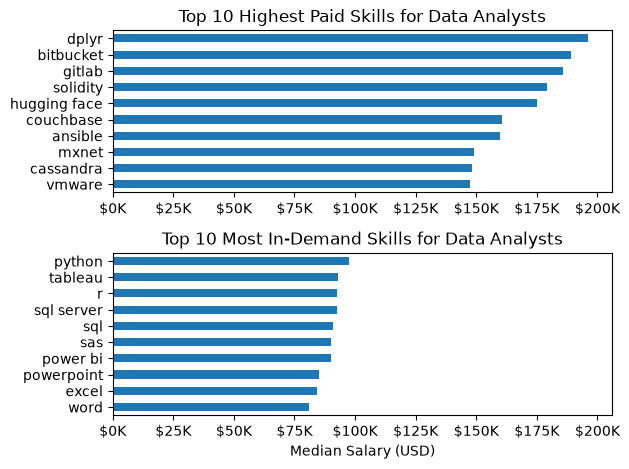

In [57]:
fig, ax = plt.subplots(2,1)

df_DA_top_pay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))


df_DA_top_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())  
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.tight_layout()
plt.show()

# Problems

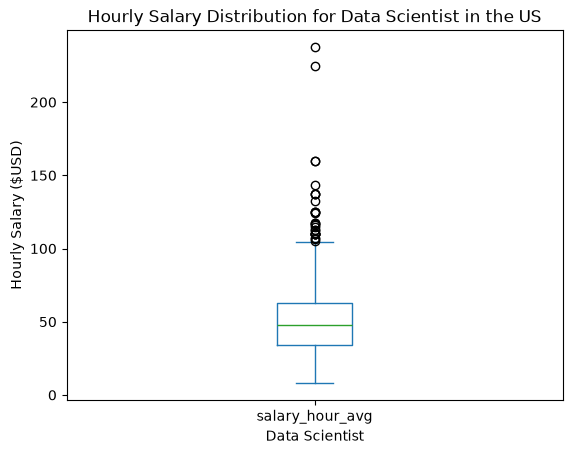

In [75]:
df_US_DS = df[(df['job_title_short'] == 'Data Scientist') & (df['job_country'] == 'United States')]
df_US_DS = df_US_DS.dropna(subset=['salary_hour_avg'])

df_US_DS['salary_hour_avg'].plot(kind='box')
plt.xlabel('Data Scientist')
plt.ylabel('Hourly Salary ($USD)')
plt.title('Hourly Salary Distribution for Data Scientist in the US')
plt.show()

In [107]:
# Create a box plot to compare the distribution of salary_hour_avg for Data Analyst job postings in the United States and Canada.

# Filter a DataFrame to include only 'Data Analyst' roles in these two countries.
# Use list comprehension to create a list of DataFrames for each country.
# Use the plt.boxplot() function to plot this list and specify the labels as countries.
# Set the y-axis limit to 150 and the y-axis as 'Hourly Salary ($USD)'.

countries = ['United States', 'Canada']

df_DA_US_CAN = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'].isin(countries))].dropna(subset=['salary_hour_avg']).copy()

country_data = [df_DA_US_CAN[df_DA_US_CAN['job_country'] == country]['salary_hour_avg'] for country in countries]



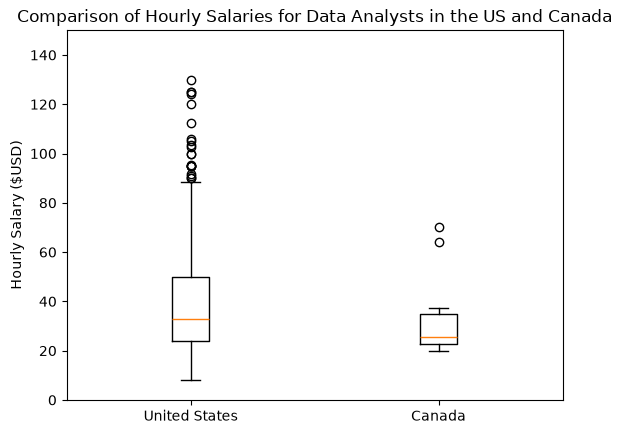

In [106]:
plt.boxplot(country_data, tick_labels=countries)
plt.xlabel('')
plt.ylabel('Hourly Salary ($USD)')
plt.ylim(0, 150)
plt.title('Comparison of Hourly Salaries for Data Analysts in the US and Canada')
plt.show()

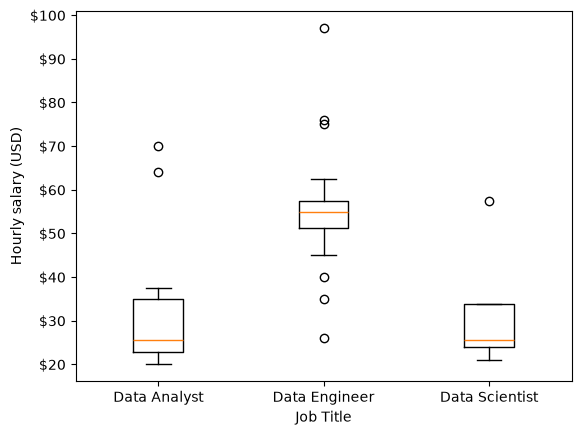

In [125]:
# Create a box plot to compare the distribution of salary_hour_avg for Data Analyst, Data Engineer, and Data Scientist job postings in Canada.
# Label the x-axis as 'Job Title' and format the y-axis to have '$' before the number then label it as 'Hourly Salary (USD)'.
import matplotlib.ticker as ticker

titles= ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_CAN = df[(df['job_country'] == 'Canada') & (df['job_title_short'].isin(titles))].dropna(subset=['salary_hour_avg']).copy()

title_stats = [df_CAN[df_CAN['job_title_short'] == title]['salary_hour_avg'] for title in titles]

plt.boxplot(title_stats, tick_labels=titles)
plt.xlabel('Job Title')
plt.ylabel('Hourly salary (USD)')
formatter = ticker.StrMethodFormatter('${x:.0f}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.show()